# Pulse Smoothing with GEOPE

This notebook demonstrates how to use **GEOPE** (Geodesic Pulse Engineering) to synthesise piecewise-constant quantum control pulses and then smooth them using two different strategies:

1. **Geometric smoothing** — iteratively projects parameter updates into the null space of the Jacobian so that fidelity is preserved while neighbouring pulse segments are brought closer together.
2. **Gaussian filtering** — a simple signal-processing baseline that convolves the pulse with a Gaussian kernel, then re-optimises to recover lost fidelity.

We target the **controlled-Z (CZ)** gate on two qubits under an Ising-type Hamiltonian with time-dependent transverse-field controls.

## Setup

Load the required libraries. **GEOPE** is built on JAX for automatic differentiation and JIT compilation. We also use SciPy for signal processing and Matplotlib (with the `scienceplots` style) for publication-quality figures.

In [ ]:
import sys

sys.path.append("../")

from geope.geope import Geope, GeopeEngine
from geope.utils import construct_full_pauli_basis, construct_restricted_pauli_basis, qft_unitary

import jax.numpy as jnp
import jax
import numpy as np
import scipy.linalg as spla
import scipy.optimize as spo
import scipy.signal as sps

import re
import matplotlib.pyplot as plt

import scienceplots
plt.style.use('science')
fontsize_title=24
fontsize_label=26
fontsize_legend=18
fontsize_ticks=22

# CZ with $h_1(t)$ control

With Hamiltonian model: $H = \sigma^z_1 \sigma^z_2 + h_1(t)\sigma^x_1$ 

### Solve with GEOPE and perform repeated Geometric smoothing steps (fewer steps would be sufficient)

We construct the CZ gate as a 2-qubit target unitary and set up the Lie algebra bases:

- **Full basis** — the complete 15-element Pauli basis for 2 qubits.
- **Drift basis** — the fixed $\sigma^z_1 \sigma^z_2$ interaction that is always on.
- **Projected (control) basis** — only $\sigma^x_1$, the single controllable field $h_1(t)$.

Two `GeopeEngine` instances are created: one for geometric smoothing and one for the Gaussian filter comparison. The optimisation loop runs GEOPE for up to 6 rounds, doubling the number of piecewise-constant segments and applying geometric smoothing after each round until the pulse-difference cost drops below the tolerance.

In [ ]:
nqubits = 2

target = np.array([[1,0,0,0],[0,1.j,0,0],[0,0,1.j,0],[0,0,0,1]])
gates = 4
basis = construct_full_pauli_basis(nqubits)
max_step_size = 0.1

drift = construct_restricted_pauli_basis(nqubits, ['zz'])
restriction = construct_restricted_pauli_basis(nqubits, {1: ['x']})


drift_parameters = [1.]

geope_engine = GeopeEngine(target_unitary=target,
                           full_basis=basis,
                           projected_basis=restriction,
                           drift_basis=drift,
                           gates=gates)

geope_engine_gf = GeopeEngine(target_unitary=target,
                              full_basis=basis,
                              projected_basis=restriction,
                              drift_basis=drift,
                              gates=gates)

opt_geope = Geope(geope_engine, 
                  drift_parameters = drift_parameters,
                  max_steps=100,
                  max_step_size=max_step_size, 
                  gram_schmidt_step_size=1.2*max_step_size, 
                  init_parameters_spread=0.1,
                  verbose=True)

c=0
success = False
steps = []
while c < 6 and not success:
    opt_geope.optimize(extra_steps=100)
    if c==0:
        opt_geope_gf = Geope(geope_engine_gf, 
                              drift_parameters = drift_parameters,
                              init_parameters=opt_geope.parameters[-1],
                              max_steps=100,
                              max_step_size=max_step_size, 
                              gram_schmidt_step_size=1.2*max_step_size, 
                              verbose=True)
        steps.append(opt_geope.steps[-1])
    success, _ = opt_geope.smooth(piecewise_steps_multiplier=2, smoothing_rate=0.001, max_smoothing_steps=500, diff_tol=0.00001)
    steps.append(opt_geope.steps[-1])
    c+=1
opt_geope.optimize(extra_steps=100)
print("Finished optimising.")

[47/200] [Fidelity = 0.9999999999993855] A solution!                                                                      
[500/500] [Fidelity = 0.999999999892188] Smoothing : cost = 0.6241215575277288 (aim = 1e-05)                        

[500/500] [Fidelity = 0.9999999963041594] Smoothing : cost = 0.07466517407061818 (aim = 1e-05)                        

[500/500] [Fidelity = 0.9999995626780503] Smoothing : cost = 0.009589935098381531 (aim = 1e-05)                        
[51/500] [Fidelity = 0.9999999999747118] A solution!                                                                     
[500/500] [Fidelity = 0.9999885767979315] Smoothing : cost = 0.0012006663522884122 (aim = 1e-05)                        
[53/600] [Fidelity = 0.9999999999040152] A solution!                                                                     
[500/500] [Fidelity = 0.9997893111268338] Smoothing : cost = 0.00014507039371467354 (aim = 1e-05)                        
[55/700] [Fidelity = 0.999999991

### Gaussian filter

As an alternative to geometric smoothing, we apply a **Gaussian filter** (from `scipy.ndimage`) to the piecewise-constant pulse. The steps are:

1. Subdivide the pulse into many fine segments (factor of 64).
2. Pad each control channel with zeros, convolve with a Gaussian kernel ($\sigma = 8$), and trim.
3. Replace the parameters with the smoothed version and re-evaluate the fidelity before and after filtering.
4. Re-optimise with GEOPE to recover any fidelity lost from the filtering.

In [52]:
import scipy.ndimage as spnimag

new_params = []
factor = 64
opt_geope_gf.smooth(piecewise_steps_multiplier=factor, smoothing_rate=0.01, max_smoothing_steps=0, diff_tol=0.01)
gates = [i for i in range(-1, opt_geope_gf.engine.gates + 2)]
x = np.array(gates).flatten()

spline_pws = opt_geope_gf.engine.gates
sigma = 8
for i, strength in enumerate(opt_geope_gf.parameters[-1].T):
    if opt_geope_gf.engine.full_basis.labels[i] in opt_geope_gf.engine.projected_basis.labels:
        strength = np.concatenate((np.zeros(5000), strength, np.zeros(5000)))
        smoothed_strength = spnimag.gaussian_filter1d(strength, sigma=sigma)
        new_params.append(smoothed_strength[5000:-5000])
    else:
        new_params.append(strength)
    # print(new_params[-1].shape)
opt_geope_gf.parameters.append(np.stack(new_params, axis=1))
opt_geope_gf.engine.gates = spline_pws

free_params = jnp.array([p[opt_geope_gf.engine.proj_drift_indices] for p in opt_geope_gf.parameters[-2]]).astype(np.complex128)
fid = opt_geope_gf.engine.fid_U_fn(opt_geope_gf.engine.compute_U_fn(free_params))
print(f"Before: {fid}")

free_params = jnp.array([p[opt_geope_gf.engine.proj_drift_indices] for p in opt_geope_gf.parameters[-1]]).astype(np.complex128)
fid = opt_geope_gf.engine.fid_U_fn(opt_geope_gf.engine.compute_U_fn(free_params))
print(f"After: {fid}")

opt_geope_gf.optimize(extra_steps=100)

[0/0] [Fidelity = 0] Smoothing : cost = inf (aim = 0.01)                        
Before: 0.9999999999993886
After: 0.9997522986573032
[2/200] [Fidelity = 0.9999999525937958] A solution!                                                                     


True

### Plot results

We compare the two smoothing strategies side-by-side. The left panel shows the original piecewise pulse (black) overlaid with the Gaussian-filtered result (blue). The right panel shows the same original pulse overlaid with the geometrically smoothed result (green). Both methods reduce high-frequency discontinuities, but geometric smoothing preserves fidelity by construction.

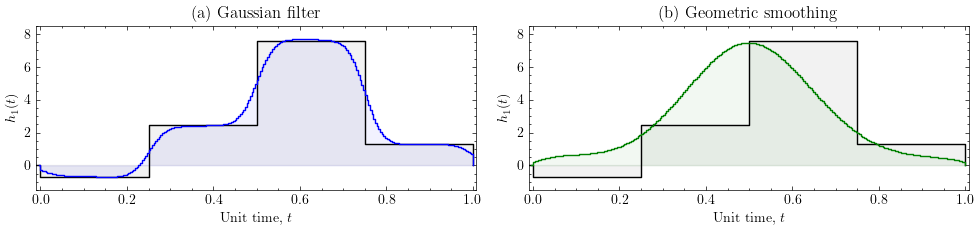

In [60]:
savefig = "plots/smoothing/gaussian_filter_vs_geometric_smoothing_cz_ising_x1.pdf"

alpha=0.05
y_limits = [-1.5,8.5]
geometric_smoothing_colour='green'
gf_smoothing_colour='blue'

orig_scaling = opt_geope.parameters[steps[0]].shape[0]
smoothed_scaling = opt_geope.parameters[-1].shape[0]
gf_scaling = opt_geope_gf.parameters[-1].shape[0]

orig_gates = [float(i)/orig_scaling for i in range(-1, opt_geope.parameters[steps[0]].shape[0]+1)]
smoothed_gates = [float(i)/smoothed_scaling for i in range(-1, opt_geope.parameters[-1].shape[0]+1)]
gf_gates = [float(i)/gf_scaling for i in range(-1, opt_geope_gf.parameters[-1].shape[0]+1)]

fig, axs = plt.subplots(1, 2, figsize=(10, 2.5), sharex=True)

for i, strength in enumerate(opt_geope.parameters[steps[0]].T):
    strength = [s*orig_scaling for s in strength]
    if opt_geope.engine.full_basis.labels[i] in opt_geope.engine.projected_basis.labels:
        axs[0].step(orig_gates, 
                    np.append(np.array([0]), np.append(strength,np.array([0]))),
                    where='post', 
                    label=opt_geope.engine.full_basis.plot_labels[i],
                    color='black')
        axs[0].fill_between(orig_gates, 
                            np.append(np.array([0]), np.append(strength,np.array([0]))), 
                            step='post', 
                            color='black', 
                            alpha=0.05)

for i, strength in enumerate(opt_geope_gf.parameters[-1].T):
    strength = [s*gf_scaling for s in strength]
    if opt_geope_gf.engine.full_basis.labels[i] in opt_geope_gf.engine.projected_basis.labels:
        axs[0].step(gf_gates, 
                    np.append(np.array([0]), np.append(strength,np.array([0]))),
                    where='post', 
                    label=opt_geope_gf.engine.full_basis.plot_labels[i],
                    color=gf_smoothing_colour)
        axs[0].fill_between(gf_gates, 
                            np.append(np.array([0]), np.append(strength,np.array([0]))), 
                            step='post', 
                            color=gf_smoothing_colour, 
                            alpha=alpha)

for i, strength in enumerate(opt_geope.parameters[steps[0]].T):
    strength = [s*orig_scaling for s in strength]
    if opt_geope.engine.full_basis.labels[i] in opt_geope.engine.projected_basis.labels:
        axs[1].step(orig_gates, 
                    np.append(np.array([0]), np.append(strength,np.array([0]))),
                    where='post', 
                    label=opt_geope.engine.full_basis.plot_labels[i],
                    color='black')
        axs[1].fill_between(orig_gates, 
                            np.append(np.array([0]), np.append(strength,np.array([0]))), 
                            step='post', 
                            color='black', 
                            alpha=0.05)
        
for i, strength in enumerate(opt_geope.parameters[-1].T):
    strength = [s*smoothed_scaling for s in strength]
    if opt_geope.engine.full_basis.labels[i] in opt_geope.engine.projected_basis.labels:
        axs[1].step(smoothed_gates, 
                    np.append(np.array([0]), np.append(strength,np.array([0]))),
                    where='post', 
                    label=opt_geope.engine.full_basis.plot_labels[i],
                    color=geometric_smoothing_colour)
        axs[1].fill_between(smoothed_gates, 
                            np.append(np.array([0]), np.append(strength,np.array([0]))), 
                            step='post', 
                            color=geometric_smoothing_colour, 
                            alpha=alpha)

        
for ax in axs:
    # ax.legend(loc='upper right')
    ax.grid(False)
    ax.set_xlim(-0.01,smoothed_gates[-1]+0.008)
    ax.set_ylim(y_limits[0],y_limits[1])

axs[0].set_title(f"(a) Gaussian filter")
axs[1].set_title(f"(b) Geometric smoothing")

axs[0].set_xlabel("Unit time, $t$")
axs[1].set_xlabel("Unit time, $t$")
axs[0].set_ylabel(f"$h_1(t)$")
axs[1].set_ylabel(f"$h_1(t)$")

plt.tight_layout()
if savefig is not None:
    plt.savefig(savefig)
plt.show()

# CZ with $h_1(t)$ and $h_2(t)$ control 

With Hamiltonian model: $H = \sigma^z_1 \sigma^z_2 + h_1(t)\sigma^x_1 + h_2(t)\sigma^x_2$ 

### Solve with GEOPE and then repeated geometric smoothing

We now repeat the experiment with **two independent controls**, $h_1(t)\sigma^x_1$ and $h_2(t)\sigma^x_2$, while keeping the same $\sigma^z_1\sigma^z_2$ drift. Having more control degrees of freedom generally makes the optimisation landscape more favourable for convergence.

In [66]:
nqubits = 2

target = np.array([[1,0,0,0],[0,1.j,0,0],[0,0,1.j,0],[0,0,0,1]])
gates = 4
basis = construct_full_pauli_basis(nqubits)
max_step_size = 0.1

drift = construct_restricted_pauli_basis(nqubits, ['zz'])
restriction = construct_restricted_pauli_basis(nqubits, {1: ['x'], 2: ['x']})


drift_parameters = [1.]

engine = GeopeEngine(target_unitary=target,
                           full_basis=basis,
                           projected_basis=restriction,
                           drift_basis=drift,
                           gates=gates)

opt = Geope(engine, 
              drift_parameters = drift_parameters,
              max_steps=100,
              max_step_size=max_step_size, 
              gram_schmidt_step_size=1.2*max_step_size, 
              init_parameters_spread=0.01,
              verbose=True)

c=0
success = False
steps_2 = []
while c < 6 and not success:
    opt.optimize(extra_steps=100)
    success, _ = opt.smooth(piecewise_steps_multiplier=2, smoothing_rate=0.001, max_smoothing_steps=500, diff_tol=0.00001)
    steps_2.append(opt.steps[-1])
    c+=1
opt.optimize(extra_steps=100)
print("Finished optimising.")

[46/200] [Fidelity = 0.9999999815404588] A solution!                                                                      
[500/500] [Fidelity = 0.999999982018949] Smoothing : cost = 0.573877544865765 (aim = 1e-05)                        

[500/500] [Fidelity = 0.9999999684720933] Smoothing : cost = 0.07467538831456612 (aim = 1e-05)                        

[500/500] [Fidelity = 0.9999992099301154] Smoothing : cost = 0.009591332856464223 (aim = 1e-05)                        
[50/500] [Fidelity = 0.999999999790611] A solution!                                                                     
[500/500] [Fidelity = 0.9999870968493517] Smoothing : cost = 0.0012002537783423056 (aim = 1e-05)                        
[52/600] [Fidelity = 0.9999999997577187] A solution!                                                                     
[500/500] [Fidelity = 0.9997854149111107] Smoothing : cost = 0.00014500395023076424 (aim = 1e-05)                        
[54/700] [Fidelity = 0.99999999118

### Plot

Each subplot shows one control channel. The black step function is the initial (unsmoothed) pulse; the green step function is the geometrically smoothed result. Both panels share the same time axis.

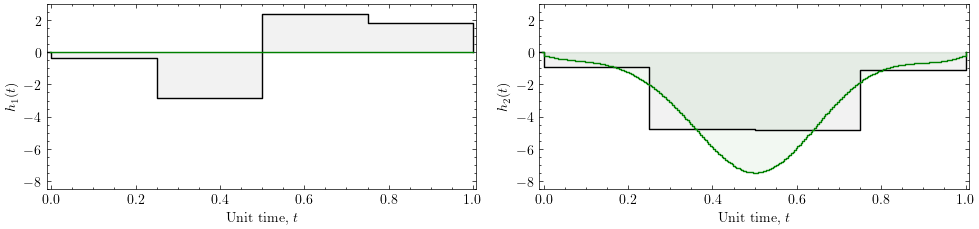

In [68]:
alpha = 0.05
y_limits = (-8.5,3)
init_step = steps_2[0]
smoothed_step = -1
init_scaling = opt.parameters[init_step].shape[0]
smoothed_scaling = opt.parameters[smoothed_step].shape[0]
gates = [float(i)/init_scaling for i in range(-1,opt.parameters[init_step].shape[0]+1)]
smoothed_gates = [float(i)/smoothed_scaling for i in range(-1,opt.parameters[smoothed_step].shape[0]+1)]

fig, axs = plt.subplots(1, 2, figsize=(10, 2.5), sharex=True)
a=0
for i, strength in enumerate(opt.parameters[init_step].T):
    strength = [s*init_scaling for s in strength]
    if opt.engine.full_basis.labels[i] in opt.engine.projected_basis.labels:
        axs[a].step(gates, 
                          np.append(np.array([0]), np.append(strength,np.array([0]))), 
                          where='post', 
                          label=opt.engine.full_basis.plot_labels[i],
                          color="black")
        axs[a].fill_between(gates, 
                                  np.append(np.array([0]), np.append(strength,np.array([0]))), 
                                  step='post', 
                                  color="black", 
                                  alpha=alpha)
        a+=1

a=0
for i, strength in enumerate(opt.parameters[smoothed_step].T):
    strength = [s*smoothed_scaling for s in strength]
    if opt.engine.full_basis.labels[i] in opt.engine.projected_basis.labels:
        axs[a].step(smoothed_gates, 
                          np.append(np.array([0]), np.append(strength,np.array([0]))), 
                          where='post', 
                          label=opt.engine.full_basis.plot_labels[i],
                          color="green")
        axs[a].fill_between(smoothed_gates, 
                                  np.append(np.array([0]), np.append(strength,np.array([0]))), 
                                  step='post', 
                                  color="green", 
                                  alpha=alpha)
        a+=1

for ax in axs:
    # ax.legend(loc='upper right')
    ax.grid(False)
    ax.set_xlim(-0.01,gates[-1]+0.008)
    ax.set_ylim(y_limits[0],y_limits[1])

axs[0].set_xlabel("Unit time, $t$")
axs[1].set_xlabel("Unit time, $t$")

axs[0].set_ylabel(f"$h_{{1}}(t)$")
axs[1].set_ylabel(f"$h_{{2}}(t)$")

plt.tight_layout()
plt.savefig("plots/smoothing/geometric_smoothing_transverse_ising_with_h1_h2.pdf")
plt.show()